# 01 - Hetionet Overview & Type Distributions

**Coverage**: Step 1 (Dataset overview) · Step 2 (Node type distribution) · Step 3 (Edge type distribution)

**Goal**: Validate official node/edge counts, quantify class imbalance, and flag key metaedges for the drug-repositioning prediction task.

In [1]:
from utils import load_hetnet, metanode_counts, metaedge_counts, setup_plot_style
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

setup_plot_style()

## Step 1 · Dataset Overview

Load the bz2 JSON and validate against the official Hetionet specs (Himmelstein et al. 2017, *eLife*).

In [2]:
hetnet = load_hetnet()
print('Top-level keys:', list(hetnet.keys()))

Top-level keys: ['metanode_kinds', 'metaedge_tuples', 'kind_to_abbrev', 'nodes', 'edges']


In [3]:
# Validate against official Hetionet specs (Himmelstein et al. 2017, eLife)
spec = {
    'nodes':           (len(hetnet['nodes']),            47031),
    'edges':           (len(hetnet['edges']),         2250197),
    'metanode_kinds':  (len(hetnet['metanode_kinds']),      11),
    'metaedge_tuples': (len(hetnet['metaedge_tuples']),     24),
}
spec_df = pd.DataFrame(spec, index=['observed', 'expected']).T
spec_df['match'] = spec_df['observed'] == spec_df['expected']
spec_df

,observed,expected,match
nodes,47031,47031,True
edges,2250197,2250197,True
metanode_kinds,11,11,True
metaedge_tuples,24,24,True


In [4]:
# Schema: 11 node types
print('Metanode kinds (11):')
for k in hetnet['metanode_kinds']:
    print(f'  · {k}')

Metanode kinds (11):
  · Anatomy
  · Biological Process
  · Cellular Component
  · Compound
  · Disease
  · Gene
  · Molecular Function
  · Pathway
  · Pharmacologic Class
  · Side Effect
  · Symptom


In [5]:
# Schema: 24 edge types (directed)
pd.DataFrame(hetnet['metaedge_tuples'], columns=['source', 'target', 'kind', 'direction'])

,source,target,kind,direction
0,Anatomy,Gene,downregulates,both
1,Anatomy,Gene,expresses,both
2,Anatomy,Gene,upregulates,both
3,Compound,Compound,resembles,both
4,Compound,Disease,palliates,both
5,Compound,Disease,treats,both
6,Compound,Gene,binds,both
7,Compound,Gene,downregulates,both
8,Compound,Gene,upregulates,both
9,Compound,Side Effect,causes,both


In [6]:
# Inspect one sample node and one sample edge
import json as _json
print('--- Sample node ---')
print(_json.dumps(hetnet['nodes'][100], indent=2, ensure_ascii=False))
print('\n--- Sample edge ---')
print(_json.dumps(hetnet['edges'][1000], indent=2, ensure_ascii=False))

--- Sample node ---
{
  "kind": "Molecular Function",
  "identifier": "GO:0032090",
  "name": "Pyrin domain binding",
  "data": {
    "source": "Gene Ontology",
    "license": "CC BY 4.0",
    "url": "http://purl.obolibrary.org/obo/GO_0032090"
  }
}

--- Sample edge ---
{
  "source_id": [
    "Gene",
    7704
  ],
  "target_id": [
    "Gene",
    23528
  ],
  "kind": "interacts",
  "direction": "both",
  "data": {
    "sources": [
      "hetio-dag"
    ],
    "unbiased": false
  }
}


## Step 2 · Node Type Distribution

How skewed is the node type distribution across the 11 metanodes?

In [7]:
node_counts = metanode_counts(hetnet)
node_counts

Gene                   20945
Biological Process     11381
Side Effect             5734
Molecular Function      2884
Pathway                 1822
Compound                1552
Cellular Component      1391
Symptom                  438
Anatomy                  402
Pharmacologic Class      345
Disease                  137
dtype: int64

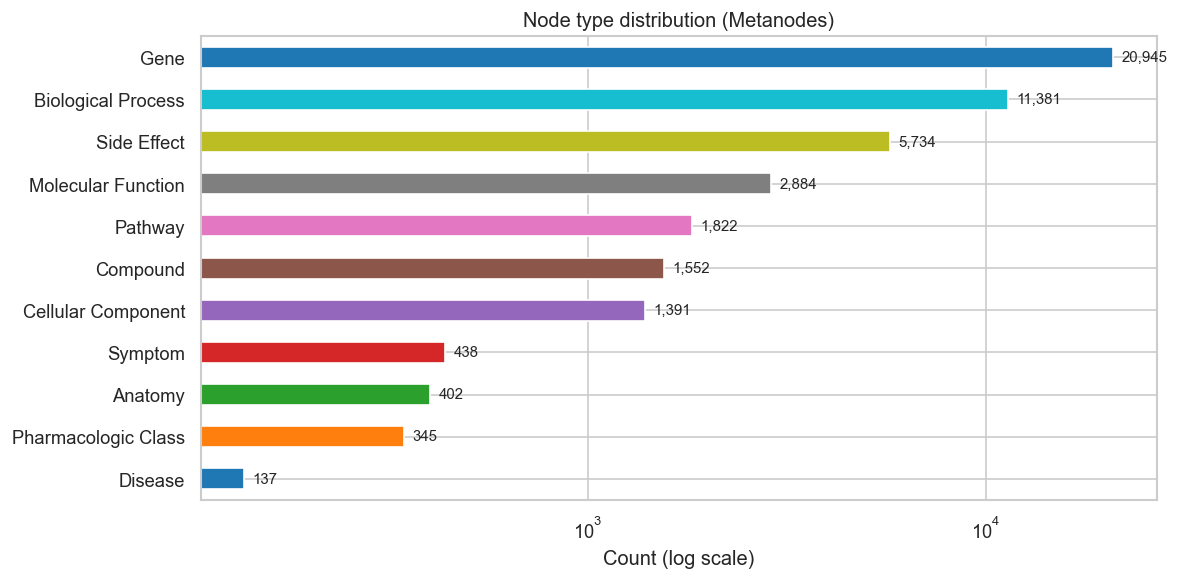

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('tab10', len(node_counts))
node_counts.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xscale('log')
ax.set_xlabel('Count (log scale)')
ax.set_title('Node type distribution (Metanodes)')
for i, v in enumerate(node_counts.sort_values().values):
    ax.text(v * 1.05, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
ratio      = node_counts.max() / node_counts.min()
top2_share = node_counts.iloc[:2].sum() / node_counts.sum()
print(f'Max/min class ratio : {ratio:.1f}x')
print(f'Top-2 types share   : {top2_share:.1%} of all nodes')

Max/min class ratio : 152.9x
Top-2 types share   : 68.7% of all nodes


**Observation**: Node counts span three orders of magnitude. Gene dominates; Disease is the smallest class (137 nodes). This extreme imbalance shapes embedding quality and drives the need for careful negative sampling.

---

## Step 3 · Edge Type Distribution

Sparsity per metaedge and identification of prediction targets.

In [10]:
edge_counts = metaedge_counts(hetnet)
edge_counts

participates     814664
expresses        526407
regulates        265672
interacts        147164
causes           138944
downregulates    130965
upregulates      124335
covaries          61690
associates        12623
binds             11571
resembles          7029
localizes          3602
presents           3357
includes           1029
treats              755
palliates           390
dtype: int64

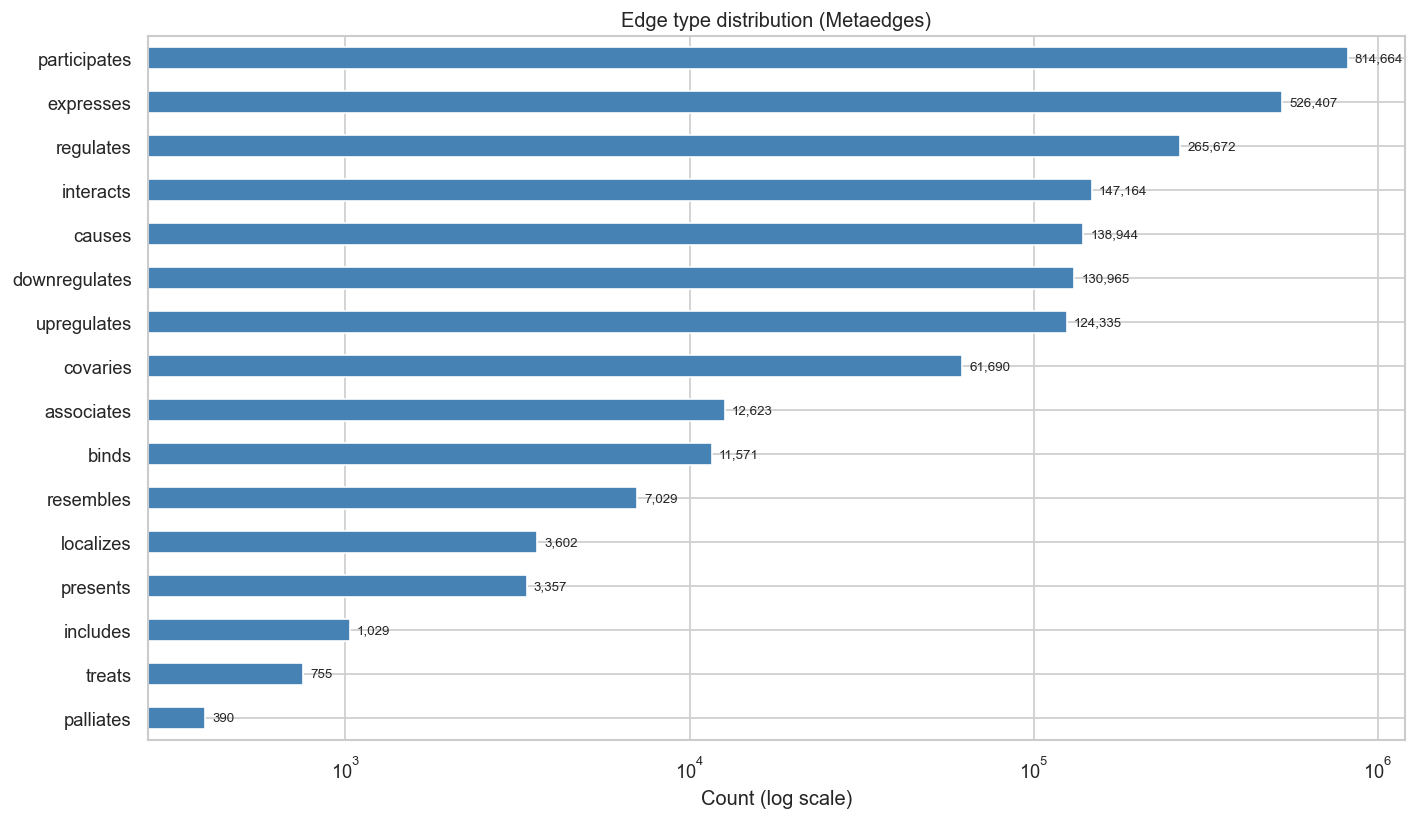

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
edge_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Count (log scale)')
ax.set_title('Edge type distribution (Metaedges)')
for i, v in enumerate(edge_counts.sort_values().values):
    ax.text(v * 1.05, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Density Analysis

For each metaedge: `density = n_edges / (|source_kind| × |target_kind|)`.

In [12]:
from collections import Counter

# metaedge -> (source_kind, target_kind)
meta_lookup = {t[2]: (t[0], t[1]) for t in hetnet['metaedge_tuples']}
# 'participates' appears across Gene-BP, Gene-MF, Gene-CC;
# aggregate by (source_kind, target_kind, edge_kind) triple
triple_counts = Counter(
    (e['source_id'][0], e['target_id'][0], e['kind']) for e in hetnet['edges']
)

rows = []
for (src, tgt, kind), n_edges in triple_counts.items():
    n_src = node_counts[src]
    n_tgt = node_counts[tgt]
    max_possible = n_src * n_tgt
    rows.append({
        'metaedge': f'{src}-{kind}-{tgt}',
        'edges': n_edges,
        'max_possible': max_possible,
        'density': n_edges / max_possible,
    })
density_df = pd.DataFrame(rows).sort_values('density', ascending=False).reset_index(drop=True)
density_df

,metaedge,edges,max_possible,density
0,Disease-localizes-Anatomy,3602,55074,0.065403
1,Anatomy-expresses-Gene,526407,8419890,0.062519
2,Disease-presents-Symptom,3357,60006,0.055944
3,Disease-resembles-Disease,543,18769,0.028931
4,Compound-causes-Side Effect,138944,8899168,0.015613
5,Anatomy-downregulates-Gene,102240,8419890,0.012143
6,Anatomy-upregulates-Gene,97848,8419890,0.011621
7,Disease-associates-Gene,12623,2869465,0.004399
8,Compound-treats-Disease,755,212624,0.003551
9,Disease-upregulates-Gene,7731,2869465,0.002694


In [13]:
prediction_targets = density_df[density_df['metaedge'].str.contains('Compound.*Disease')]
print('=== Drug-repositioning metaedges ===')
prediction_targets

=== Drug-repositioning metaedges ===


,metaedge,edges,max_possible,density
8,Compound-treats-Disease,755,212624,0.003551
16,Compound-palliates-Disease,390,212624,0.001834


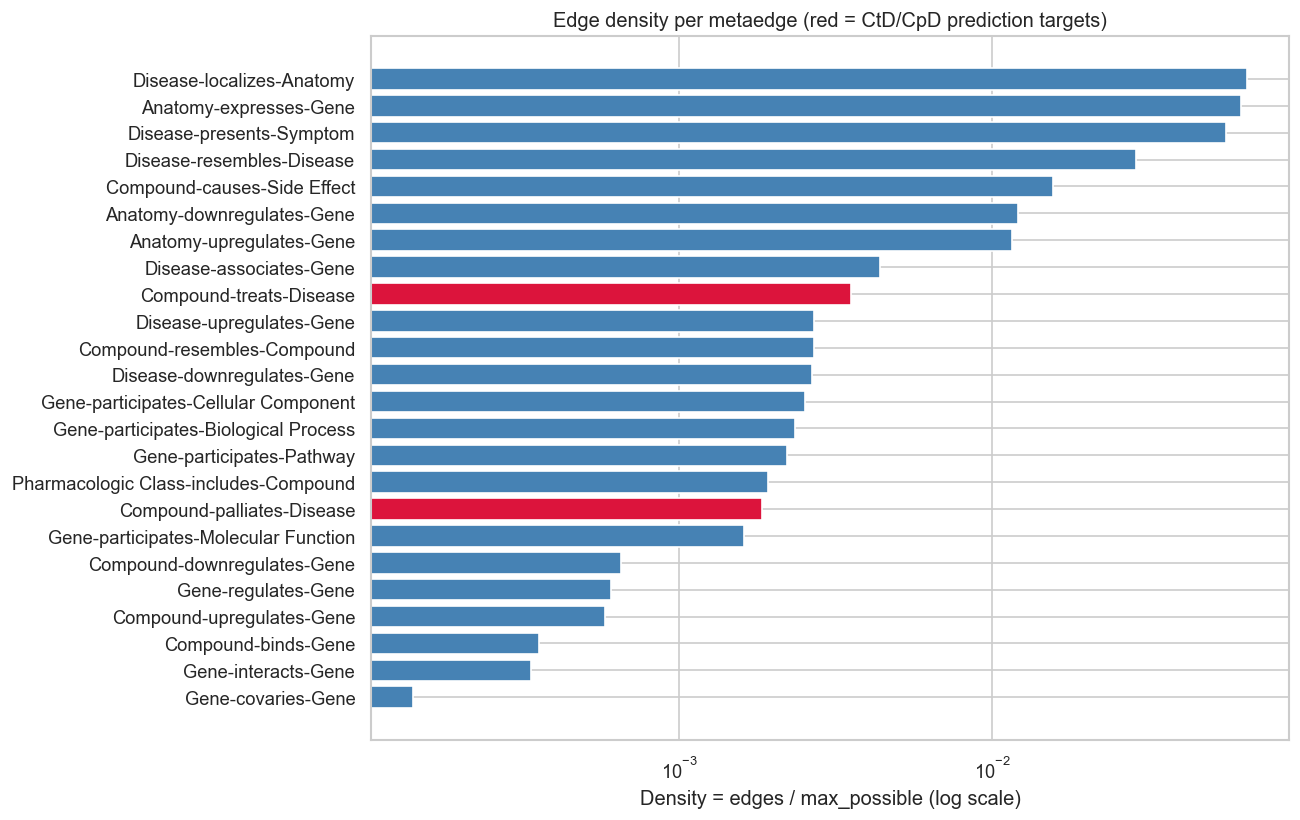

In [14]:
# Density distribution — highlight prediction targets
fig, ax = plt.subplots(figsize=(11, 7))
density_df_sorted = density_df.sort_values('density')
colors_bar = ['crimson' if 'Compound' in m and 'Disease' in m else 'steelblue'
              for m in density_df_sorted['metaedge']]
ax.barh(density_df_sorted['metaedge'], density_df_sorted['density'], color=colors_bar)
ax.set_xscale('log')
ax.set_xlabel('Density = edges / max_possible (log scale)')
ax.set_title('Edge density per metaedge (red = CtD/CpD prediction targets)')
plt.tight_layout()
plt.show()

### Class Imbalance Implications

- CtD / CpD density < 1% — extreme label sparsity
- Treating every unknown pair as a negative creates severe class imbalance
- **Mitigation**:
  1. Degree-weighted negative sampling (suppress popularity bias)
  2. **AUPRC** as the primary metric (AUROC is uninformative under extreme imbalance)
  3. **Degree-Weighted Path Count (DWPC)** features to control hub-node inflation

---

**Next**: `02_structure.ipynb` — subgraph degree distribution, connectivity, and centrality.